# ASHMED 与 HDMT、MDACT、MLFDR：读取两套历史数据的比较

本 notebook 按用户提供的 **ASHMED PDF 第2.1–2.2节数学方法**独立编写 R 插件，比较四种方法。论文实验部分没有用于选择数据、参数或方法排名。

**只读取已经生成的两套正式数据，不重新生成数据。** 第一套来自01的论文模型增强信号实验，第二套来自02的固定效应教学实验。两套各720份数据，均为 n=300、m=1000、τ=1.3/1.5/1.9、稀疏/密集、线性/已测混杂/二元结局、每条件40次、q=0.05。继续使用原FDR、Power、MCSE、近似区间和同一数据内的配对比较。

交付版本已在 R 内核运行，保留完整输出；同名HTML可直接阅读。数学推导及补全说明见 `docs/ASHMED_METHOD.md`。该插件是根据附件公式的独立实现，不代表作者官方软件。

In [1]:
find_project_root <- function(start = getwd()) {
  path <- normalizePath(start, winslash="/", mustWork=TRUE)
  for (i in 1:8) {
    if (file.exists(file.path(path,"R/bootstrap.R"))) return(path)
    candidate <- file.path(path,"mlfdr_simulation_lab")
    if (file.exists(file.path(candidate,"R/bootstrap.R"))) return(candidate)
    path <- dirname(path)
  }
  stop("请从工程目录或 notebooks 目录启动 Jupyter。")
}
PROJECT_ROOT <- find_project_root()
source(file.path(PROJECT_ROOT,"R/bootstrap.R"),encoding="UTF-8")
source(file.path(PROJECT_ROOT,"R/ashmed_comparison.R"),encoding="UTF-8")
options(repr.plot.width=10,repr.plot.height=7,repr.plot.res=145,
        repr.matrix.max.rows=80,repr.matrix.max.cols=18)
check_dependencies()

# 控制区：替换为已经存在的data_id和对应三方法baseline_run即可换数据。
# 不修改原DGP、种子、q或三个原方法选项；配置从baseline的config.rds读取。
SAVED_SOURCES <- list(
  paper_adjusted=list(label="Dataset 1: paper-adjusted",data_id="data_f87521c2b4eb",
                      baseline_run="run_2836e6c08e18"),
  teaching_fixed=list(label="Dataset 2: teaching-fixed",data_id="data_c054ed713a76",
                      baseline_run="run_af52854e0ae0")
)
WORKERS <- 4L
ADDITIONAL_METHOD_OPTIONS <- list(ASHMED=list(
  J=12L,r_min=.25,r_max=8,correlations=c(-.5,0,.5),
  initial_pi=c(H00=.85,H10=.1,H01=.1,H11=.05), # 插件将其归一化，原文合计1.10
  relative_tolerance=1e-8,kkt_tolerance=1e-4,max_iter=5000L,
  accelerate=TRUE,fit_subset=NULL,posterior_chunk_size=5000L
))
inputs <- read_ashmed_inputs(PROJECT_ROOT,SAVED_SOURCES,ADDITIONAL_METHOD_OPTIONS,WORKERS)
registry <- load_method_registry(PROJECT_ROOT)
IRdisplay::display(registry_info(registry[inputs[[1]]$config$methods]))
inventory <- do.call(rbind,lapply(names(inputs),function(label) {
  x <- inputs[[label]]
  data.frame(dataset=label,data_id=x$manifest$data_id,profile=x$config$dgp_profile,
             n=x$config$n,m=x$config$m,repetitions=x$config$repetitions,
             saved_datasets=nrow(x$manifest$design),q=x$config$q,
             methods=paste(x$config$methods,collapse=", "))
}))
inventory

,package,version
,<chr>,<chr>
HDMT,HDMT,1.0.5
MLFDR,MLFDR,0.1.0
NMOF,NMOF,2.11.0
ggplot2,ggplot2,4.0.3
IRkernel,IRkernel,1.3.2


,method,adapter_version,packages,description
,<chr>,<chr>,<chr>,<chr>
HDMT,HDMT,1.0.0,HDMT,HDMT::fdr_est (paper uses exact=0)
MDACT,MDACT,1.1.0,HDMT,Author MDACT FDR threshold with equivalent analytic null CDF
MLFDR,MLFDR,2.0.0,MLFDR,Paper four-state EM or MLFDR::localFDR + adaptive step-up; engine in config
ASHMED,ASHMED,1.0.0,,Independent ASHMED Section 2.2: fixed zero-centred four-state shrinkage mixture


dataset,data_id,profile,n,m,repetitions,saved_datasets,q,methods
<chr>,<chr>,<chr>,<int>,<int>,<int>,<int>,<dbl>,<chr>
paper_adjusted,data_f87521c2b4eb,paper_adjusted,300,1000,40,720,0.05,"HDMT, MDACT, MLFDR, ASHMED"
teaching_fixed,data_c054ed713a76,teaching_fixed,300,1000,40,720,0.05,"HDMT, MDACT, MLFDR, ASHMED"


## 两套数据读入后是什么样

每份RDS包含共同暴露X、可选已测混杂Z、300×1000的中介矩阵M、同尺寸的逐路径结局矩阵Y，以及独立真值表。每列是一条候选中介路径，分析时逐路径回归。四类状态为H00、H10、H01、H11；只有H11是真中介。

| 设计 | 第一套：paper_adjusted | 第二套：teaching_fixed |
|:--|:--|:--|
| 暴露X | Bernoulli(0.1)，人数随机 | 两组各150人，随机打乱 |
| 四类路径 | 按稀疏/密集比例随机抽取 | 固定880/50/50/20或400/200/200/200，随机打乱 |
| 非零α | N(0.35τ, 1/n)，第二参数是方差 | 固定0.2τ |
| 非零β | N(−0.5τ, 4/n)，第二参数是方差 | 固定+0.5τ |
| 直接效应 | N(1, 0.5)，第二参数是方差 | 固定0.2 |
| 已测混杂 | θ、δ独立Uniform(0,0.5)，回归调整Z | θ=δ=0.3，回归调整Z |
| 连续/二元结局 | 正态噪声线性模型 / Logistic Bernoulli | 同样两类模型 |

这些设计差别沿用历史文件；本notebook没有为ASHMED修改信号。各方法读取同一组OLS或Logistic系数及标准误。真值仅在拟合后评估FDR/Power、解释示例时使用，方法输入中排除真值。

In [2]:
for (label in names(inputs)) {
  x <- inputs[[label]]
  idx <- which(x$manifest$design$scenario=="linear" & x$manifest$design$mixture=="dense" &
                 x$manifest$design$tau==1.5 & x$manifest$design$replicate==1L)[1]
  data <- read_dataset(x$manifest,x$manifest$design$case_id[idx])
  estimates <- estimate_coefficients(data)$estimates
  stopifnot(!("truth" %in% names(make_method_input(data,estimates))))
  cat("\n",label,"：M维度",paste(dim(data$M),collapse=" × "),
      "；Y维度",paste(dim(data$Y),collapse=" × "),"\n")
  IRdisplay::display(as.data.frame(table(data$truth$state)))
  IRdisplay::display(head(estimates,4))
}

Var1,Freq
<fct>,<int>
H00,423
H01,186
H10,200
H11,191


,pathway_id,alpha_hat,beta_hat,var_alpha,var_beta,se_alpha,se_beta,p_alpha,p_beta
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
pathway_0001,pathway_0001,0.64728241,-0.02057956,0.03513290,0.004004428,0.1874377,0.06328055,0.0006339861,7.452499e-01
pathway_0002,pathway_0002,-0.04174751,-0.88696517,0.04901528,0.002990189,0.2213940,0.05468262,0.8505608591,1.000000e-17
pathway_0003,pathway_0003,-0.24457735,0.07956305,0.04411224,0.003341951,0.2100291,0.05780961,0.2451558973,1.697672e-01
pathway_0004,pathway_0004,0.35875293,-0.02839323,0.04049184,0.003422353,0.2012259,0.05850088,0.0756306645,6.277880e-01


Var1,Freq
<fct>,<int>
H00,400
H01,200
H10,200
H11,200


,pathway_id,alpha_hat,beta_hat,var_alpha,var_beta,se_alpha,se_beta,p_alpha,p_beta
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
pathway_0001,pathway_0001,-0.09341045,0.71046750,0.01167046,0.004482782,0.1080299,0.06695358,0.38791417,1.000000e-17
pathway_0002,pathway_0002,-0.01264594,0.71938103,0.01261267,0.003384415,0.1123061,0.05817573,0.91042157,1.000000e-17
pathway_0003,pathway_0003,0.20494677,0.04235802,0.01491862,0.003268810,0.1221418,0.05717351,0.09440699,4.593588e-01
pathway_0004,pathway_0004,0.01136044,0.76751018,0.01406780,0.003066749,0.1186078,0.05537824,0.92375841,1.000000e-17



 paper_adjusted ：M维度 300 × 1000 ；Y维度 300 × 1000 

 teaching_fixed ：M维度 300 × 1000 ；Y维度 300 × 1000 


## ASHMED 的数学模型

记每条路径的观测估计为 $\hat\theta_i=(\hat\alpha_i,\hat\beta_i)^T$，真实效应为 $\theta_i$。附件第9页采用

\[
\hat\theta_i\mid\theta_i\sim N_2(\theta_i,S_i),\qquad
S_i=\operatorname{diag}(s_{\alpha i}^2,s_{\beta i}^2).
\]

默认使用文中的**采样协方差对角近似**。插件也支持输入`cov_alpha_beta`，提供时必须组成正定的采样协方差；这里已有估计不包含该列，所以使用0。先验中的ρ描述真实效应关联，与采样误差协方差是两个参数。

第10–11页的先验成分全部以0为均值：H00为原点质量，H10在α轴上，H01在β轴上，H11为二维正态。尺度网格为

\[
r_j=.25(8/.25)^{(j-1)/11},\quad
u_j=(r_j\operatorname{median}(s_\alpha))^2,\quad
v_j=(r_j\operatorname{median}(s_\beta))^2.
\]

各成分的先验协方差U为：H00=0；H10=diag($u_j$,0)；H01=diag(0,$v_j$)；H11=$\begin{pmatrix}u_j&\rho\sqrt{u_jv_j}\\\rho\sqrt{u_jv_j}&v_j\end{pmatrix}$，ρ∈{−0.5,0,0.5}。

**H11严格使用同一j的same-scale构造。** 因此总数是1+12+12+36=61个成分。尺度从观测标准误构建，均值和方差网格固定，只估计混合权重。

## 拟合、后验和筛选

设 $w_k=\pi_{T(k)}\omega_k$，则附件第12–13页的层次混合可等价展开为

\[
L_{ik}=\phi_2(\hat\theta_i;0,S_i+U_k),\quad
\ell(w)=\sum_i\log\sum_k w_kL_{ik},\qquad w_k\ge0,\ \sum_k w_k=1.
\]

EM的E步为 $r_{ik}=w_kL_{ik}/\sum_h w_hL_{ih}$，M步为 $w_k^{new}=m^{-1}\sum_i r_{ik}$。按状态求和恢复π，除以π恢复状态内ω，和文中分别更新π与ω完全等价。这里m=1000，与文中测试数p对应。

四状态后验 $\gamma_{i,T}=\sum_{k:T(k)=T}r_{ik}$；local FDR为 $1-\gamma_{i,H11}$。按local FDR从小到大排序，选最大的k使前k项平均≤q=0.05。零发现、全部发现及相同分数的边界均由现有筛选器处理。

### 明确补全的细节

1. 原文第13页初始π=(0.85,0.10,0.10,0.05)合计1.10；初始化时归一化，状态内ω均匀。
2. 用log密度与逐行减最大值避免下溢；轴先验与点质量保留为精确的退化分布。某状态拟合权重为0时，其条件ω用均匀值占位，联合权重仍为0。
3. 使用同一无惩罚似然的EM、单调性保护的加速提议，以及在EM停滞时的单纯形顶点线搜索。数值设置为相对似然变化≤1e−8、KKT gap≤1e−4、最多5000轮。它们提高优化精度，未加入先验均值或权重惩罚。
4. 固定网格下ℓ对w是凹函数。令 $g_k=m^{-1}\sum_iL_{ik}/\sum_hw_hL_{ih}$，`dual_gap=max(g)-1`。满足KKT意味着没有明显可改善的权重方向；`m*dual_gap`是对数似然最优值差的上界。重叠成分的权重可能不唯一，不能把每个ω都解释成稳定参数。
5. 每份数据只用1000条路径全量拟合。可选`fit_subset`实现文中“大规模先拟合子集、再预测全部”的策略；主比较关闭它。后验可分块计算。
6. PDF数学推导针对线性结局。二元历史数据用已有Logistic系数和标准误代入正态摘要似然，明确记为 **GLM正态摘要扩展**；这里αβ不是结局概率尺度上的自然间接效应。

## 补全效应收缩与不确定性

附件引言提到效应收缩，但数学输出部分主要给状态后验和local FDR。这里用正态共轭补全效应矩。对于每个成分，

\[
b_{ik}=U_k(S_i+U_k)^{-1}\hat\theta_i,\quad
C_{ik}=U_k-U_k(S_i+U_k)^{-1}U_k.
\]

这两个公式只需要求逆$S_i+U_k$，适用于点质量与轴成分。混合后验均值是 $\sum_kr_{ik}b_{ik}$，方差使用全概率方差公式，含状态和成分间的不确定性。间接效应的后验均值为

\[
E(\alpha_i\beta_i\mid\text{data})=\sum_kr_{ik}
\{b_{ik,\alpha}b_{ik,\beta}+C_{ik,\alpha\beta}\}.
\]

因此不能简单相乘两个收缩后的边际均值。产品方差通过二元正态的四阶矩再混合计算，完整公式见方法文档。输出SD描述经验贝叶斯插件后验，不把“均值±1.96SD”当作这个含点质量混合分布的精确可信区间；未包含估计混合权重的不确定性。这些效应矩用于解释，不改变local FDR筛选。

## 运行四方法比较：沿用原指标

每次重复记录发现数R、假发现数V、真发现数S、真中介数A：FDP=V/max(R,1)，Power=S/A。**经验FDR是40次FDP的平均**，MCSE=重复间SD/√40；阴影为原先同样的近似95%蒙特卡洛均值区间，全零/全一时保留端点不确定性。配对差在同一份保存数据内计算。

三种原方法的参数和缓存沿用原实验。逐项核对R/V/S/A/FDP/Power与原结果一致，且不重新计算三个方法。新结果保存到独立目录，逐次记录错误、警告、收敛信息、环境及源码指纹。另核对所有原始数据的MD5、修改时间和manifest未改变。

In [3]:
suite <- run_ashmed_suite(inputs,PROJECT_ROOT,registry)
for (label in names(suite)) {
  x <- suite[[label]]
  cat("\n",label,"结果目录：",x$experiment$output_dir,"\n")
  cat("成功调用：",sum(x$experiment$metrics$status=="ok"),"/",nrow(x$experiment$metrics),"\n")
  IRdisplay::display(x$baseline_audit)
  IRdisplay::display(x$data_audit)
}

Four-method comparison on saved data: paper_adjusted



Analysed 12/720 saved datasets; method errors: 0



Analysed 24/720 saved datasets; method errors: 0



Analysed 36/720 saved datasets; method errors: 0



Analysed 48/720 saved datasets; method errors: 0



...

metric,n_compared,max_absolute_difference,unchanged
<chr>,<int>,<dbl>,<lgl>
discoveries,2160,0.000000e+00,TRUE
false_discoveries,2160,0.000000e+00,TRUE
true_discoveries,2160,0.000000e+00,TRUE
alternatives,2160,0.000000e+00,TRUE
FDP,2160,4.996004e-16,TRUE
power,2160,4.996004e-16,TRUE


data_id,datasets,checksum_matches,mtime_unchanged,manifest_unchanged
<chr>,<int>,<int>,<lgl>,<lgl>
data_f87521c2b4eb,720,720,TRUE,TRUE


metric,n_compared,max_absolute_difference,unchanged
<chr>,<int>,<dbl>,<lgl>
discoveries,2160,0.000000e+00,TRUE
false_discoveries,2160,0.000000e+00,TRUE
true_discoveries,2160,0.000000e+00,TRUE
alternatives,2160,0.000000e+00,TRUE
FDP,2160,4.857226e-16,TRUE
power,2160,0.000000e+00,TRUE


data_id,datasets,checksum_matches,mtime_unchanged,manifest_unchanged
<chr>,<int>,<int>,<lgl>,<lgl>
data_c054ed713a76,720,720,TRUE,TRUE



 paper_adjusted 结果目录： D:/A_Mediation_analysis/code/mlfdr_simulation_lab/results/run_76428dee9701 
成功调用： 2880 / 2880 

 teaching_fixed 结果目录： D:/A_Mediation_analysis/code/mlfdr_simulation_lab/results/run_17d85e6975d0 
成功调用： 2880 / 2880 


## 第一套：论文模型增强信号数据

各场景图沿用原布局：左列FDR、右列Power，上排稀疏、下排密集；虚线为q=0.05。表格同时保留MCSE、成功数、错误数、警告数。

### 连续线性结局

,mixture,tau,method,n_success,n_error,n_warning,FDR_mean,FDR_mcse,power_mean,power_mcse
,<chr>,<dbl>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
49,dense,1.3,ASHMED,40,0,0,0.0074,0.0020,0.2367,0.0151
50,dense,1.3,HDMT,40,0,40,0.0305,0.0034,0.3808,0.0200
51,dense,1.3,MDACT,40,0,40,0.0403,0.0033,0.4390,0.0188
52,dense,1.3,MLFDR,40,0,0,0.0429,0.0027,0.6946,0.0154
53,dense,1.5,ASHMED,40,0,0,0.0123,0.0018,0.4107,0.0195
54,dense,1.5,HDMT,40,0,40,0.0319,0.0027,0.5574,0.0188
55,dense,1.5,MDACT,40,0,40,0.0423,0.0028,0.5999,0.0167
56,dense,1.5,MLFDR,40,0,0,0.0560,0.0027,0.8163,0.0103
57,dense,1.9,ASHMED,40,0,0,0.0278,0.0025,0.7825,0.0228


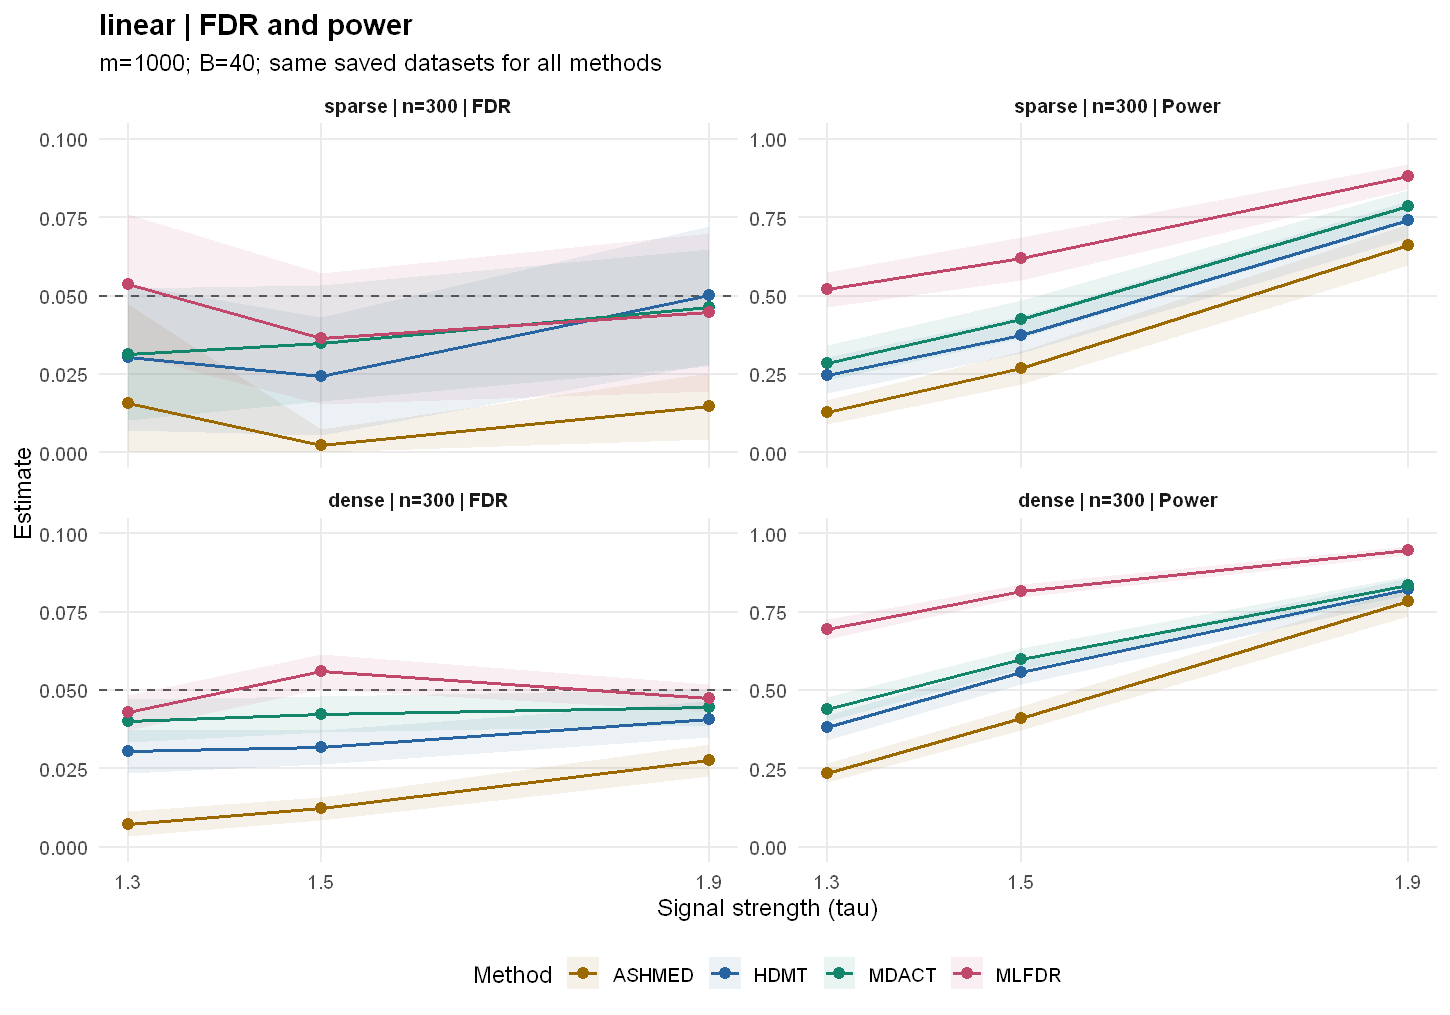

In [4]:
x <- suite[["paper_adjusted"]]
print(plot_ashmed_comparison(x$experiment$summary,"linear"))
tab <- x$experiment$summary[x$experiment$summary$scenario=="linear",
  c("mixture","tau","method","n_success","n_error","n_warning","FDR_mean","FDR_mcse","power_mean","power_mcse")]
numeric <- vapply(tab,is.numeric,logical(1))
tab[numeric] <- lapply(tab[numeric],round,4)
IRdisplay::display(tab)

### 已测混杂并调整Z

,mixture,tau,method,n_success,n_error,n_warning,FDR_mean,FDR_mcse,power_mean,power_mcse
,<chr>,<dbl>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
25,dense,1.3,ASHMED,40,0,0,0.0115,0.0021,0.2461,0.0141
26,dense,1.3,HDMT,40,0,40,0.0323,0.0034,0.3905,0.0174
27,dense,1.3,MDACT,40,0,40,0.0433,0.0036,0.4592,0.0148
28,dense,1.3,MLFDR,40,0,0,0.0538,0.0027,0.6995,0.0116
29,dense,1.5,ASHMED,40,0,0,0.0101,0.0019,0.4142,0.0155
30,dense,1.5,HDMT,40,0,40,0.0331,0.0030,0.5632,0.0153
31,dense,1.5,MDACT,40,0,40,0.0408,0.0033,0.6083,0.0138
32,dense,1.5,MLFDR,40,0,0,0.0481,0.0026,0.8292,0.0079
33,dense,1.9,ASHMED,40,0,0,0.0226,0.0023,0.7815,0.0198


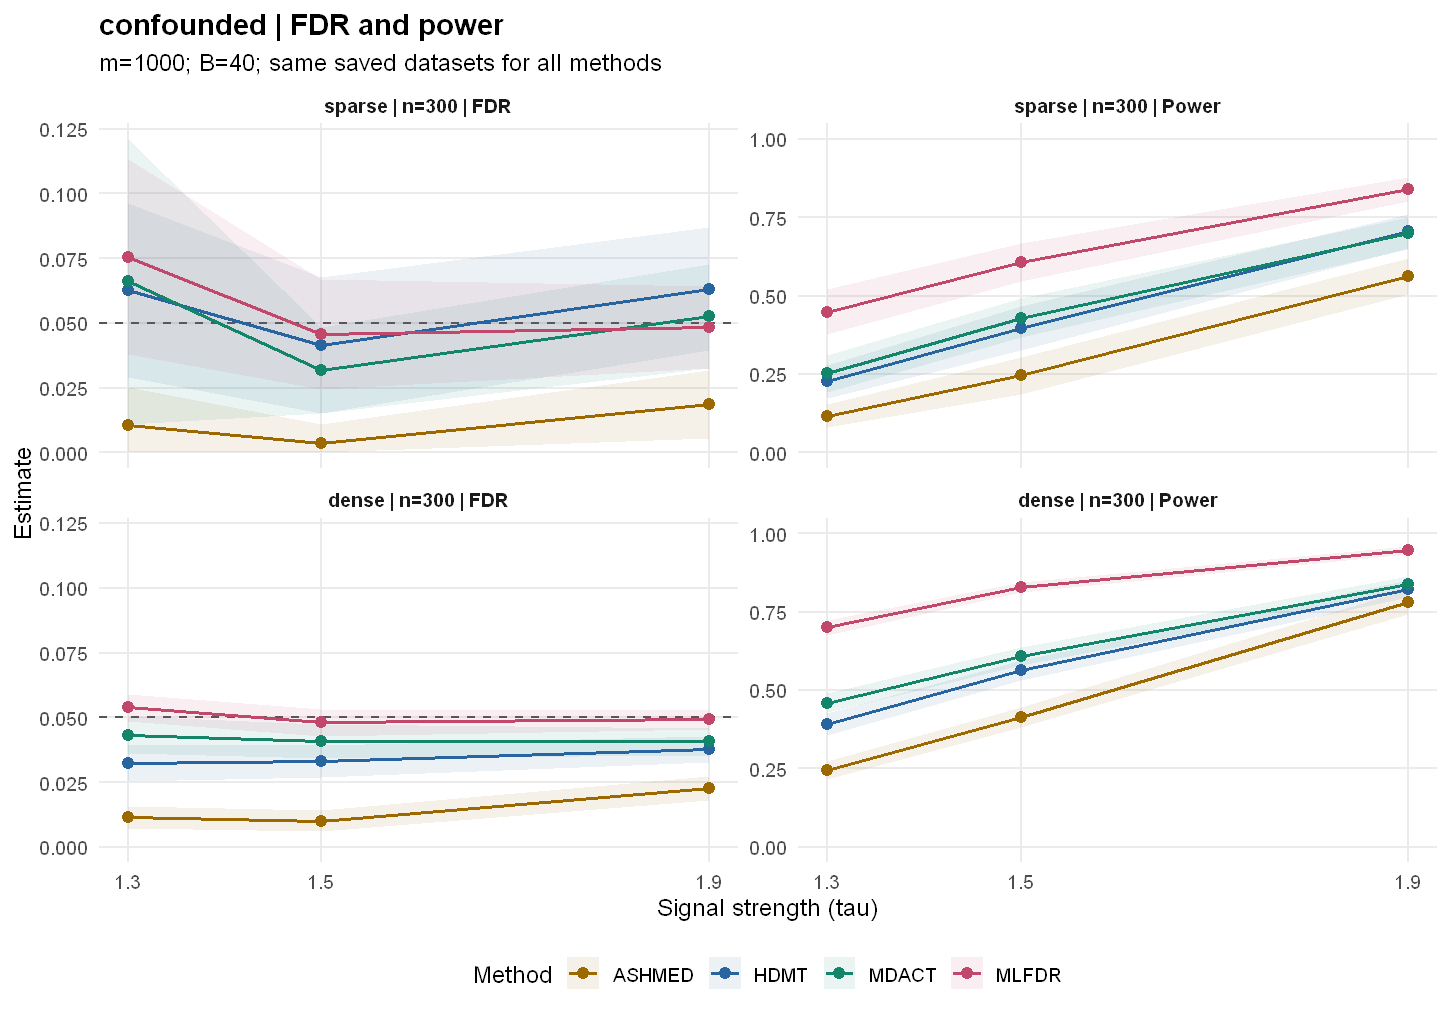

In [5]:
x <- suite[["paper_adjusted"]]
print(plot_ashmed_comparison(x$experiment$summary,"confounded"))
tab <- x$experiment$summary[x$experiment$summary$scenario=="confounded",
  c("mixture","tau","method","n_success","n_error","n_warning","FDR_mean","FDR_mcse","power_mean","power_mcse")]
numeric <- vapply(tab,is.numeric,logical(1))
tab[numeric] <- lapply(tab[numeric],round,4)
IRdisplay::display(tab)

### 二元结局：ASHMED使用GLM正态摘要扩展

,mixture,tau,method,n_success,n_error,n_warning,FDR_mean,FDR_mcse,power_mean,power_mcse
,<chr>,<dbl>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,dense,1.3,ASHMED,40,0,0,0.0573,0.0050,0.4078,0.0206
2,dense,1.3,HDMT,40,0,0,0.0266,0.0039,0.3527,0.0176
3,dense,1.3,MDACT,40,0,0,0.0394,0.0037,0.4144,0.0171
4,dense,1.3,MLFDR,40,0,0,0.0461,0.0032,0.6443,0.0172
5,dense,1.5,ASHMED,40,0,0,0.0399,0.0033,0.6413,0.0164
6,dense,1.5,HDMT,40,0,0,0.0349,0.0029,0.5941,0.0142
7,dense,1.5,MDACT,40,0,0,0.0419,0.0033,0.6394,0.0120
8,dense,1.5,MLFDR,40,0,0,0.0449,0.0025,0.8366,0.0083
9,dense,1.9,ASHMED,40,0,0,0.0669,0.0043,0.8809,0.0133


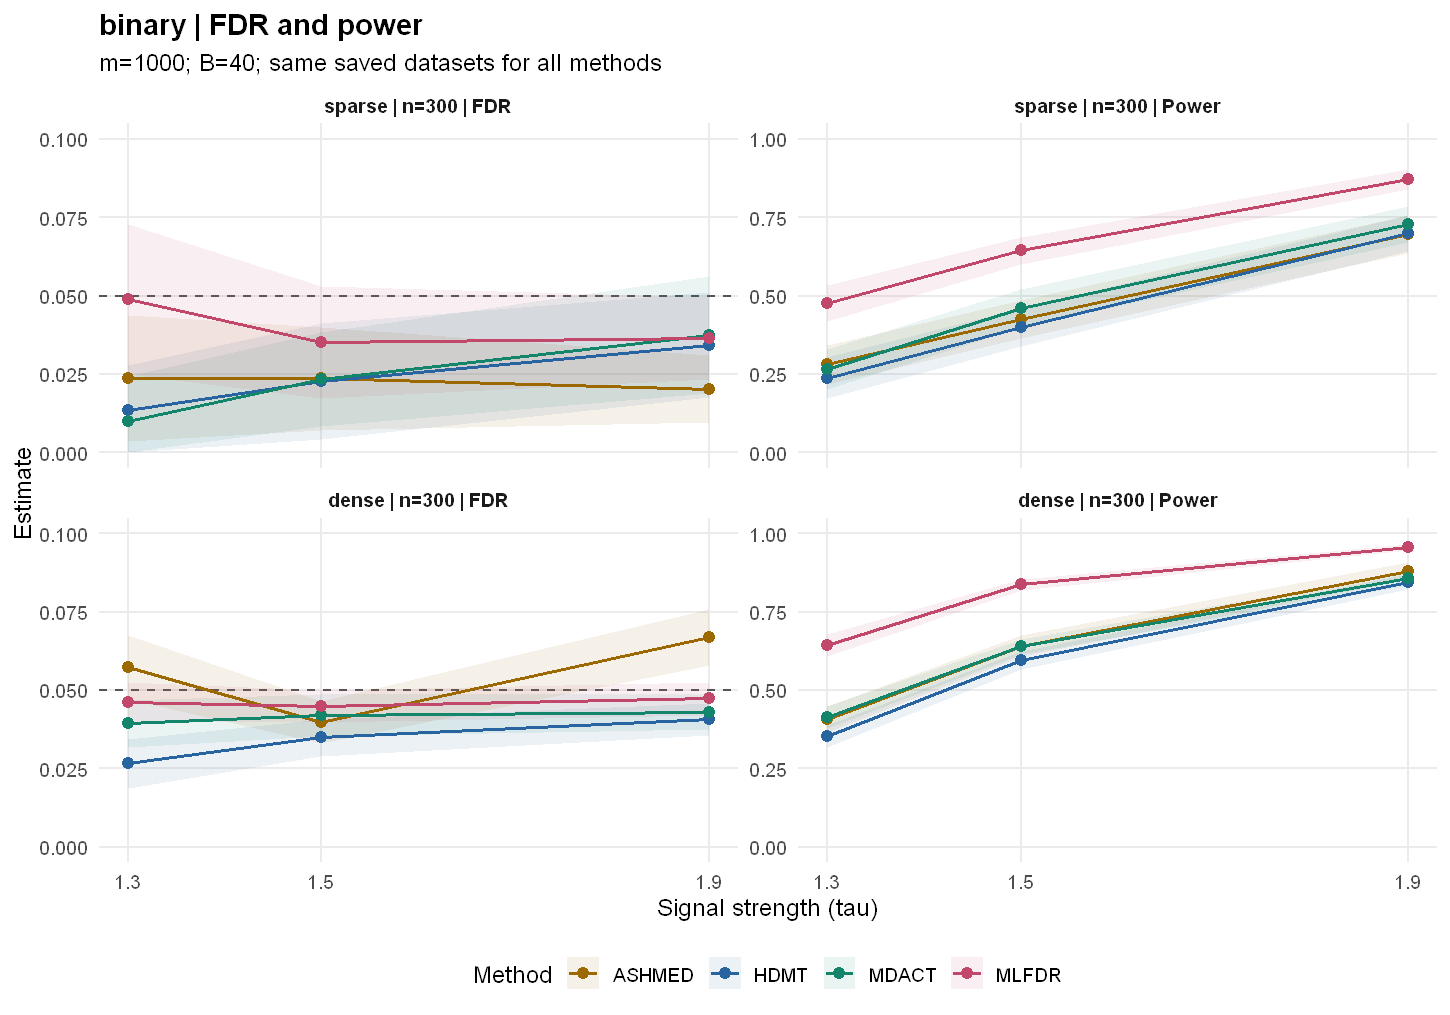

In [6]:
x <- suite[["paper_adjusted"]]
print(plot_ashmed_comparison(x$experiment$summary,"binary"))
tab <- x$experiment$summary[x$experiment$summary$scenario=="binary",
  c("mixture","tau","method","n_success","n_error","n_warning","FDR_mean","FDR_mcse","power_mean","power_mcse")]
numeric <- vapply(tab,is.numeric,logical(1))
tab[numeric] <- lapply(tab[numeric],round,4)
IRdisplay::display(tab)

## 第二套：固定效应教学数据

各场景图沿用原布局：左列FDR、右列Power，上排稀疏、下排密集；虚线为q=0.05。表格同时保留MCSE、成功数、错误数、警告数。

### 连续线性结局

,mixture,tau,method,n_success,n_error,n_warning,FDR_mean,FDR_mcse,power_mean,power_mcse
,<chr>,<dbl>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
49,dense,1.3,ASHMED,40,0,0,0.0102,0.0026,0.1714,0.0068
50,dense,1.3,HDMT,40,0,40,0.0307,0.0030,0.3190,0.0087
51,dense,1.3,MDACT,40,0,40,0.0419,0.0034,0.3781,0.0095
52,dense,1.3,MLFDR,40,0,0,0.0498,0.0031,0.6491,0.0066
53,dense,1.5,ASHMED,40,0,0,0.0113,0.0022,0.3385,0.0074
54,dense,1.5,HDMT,40,0,40,0.0345,0.0029,0.5171,0.0115
55,dense,1.5,MDACT,40,0,40,0.0388,0.0029,0.5630,0.0119
56,dense,1.5,MLFDR,40,0,0,0.0496,0.0024,0.7979,0.0073
57,dense,1.9,ASHMED,40,0,0,0.0207,0.0021,0.7616,0.0053


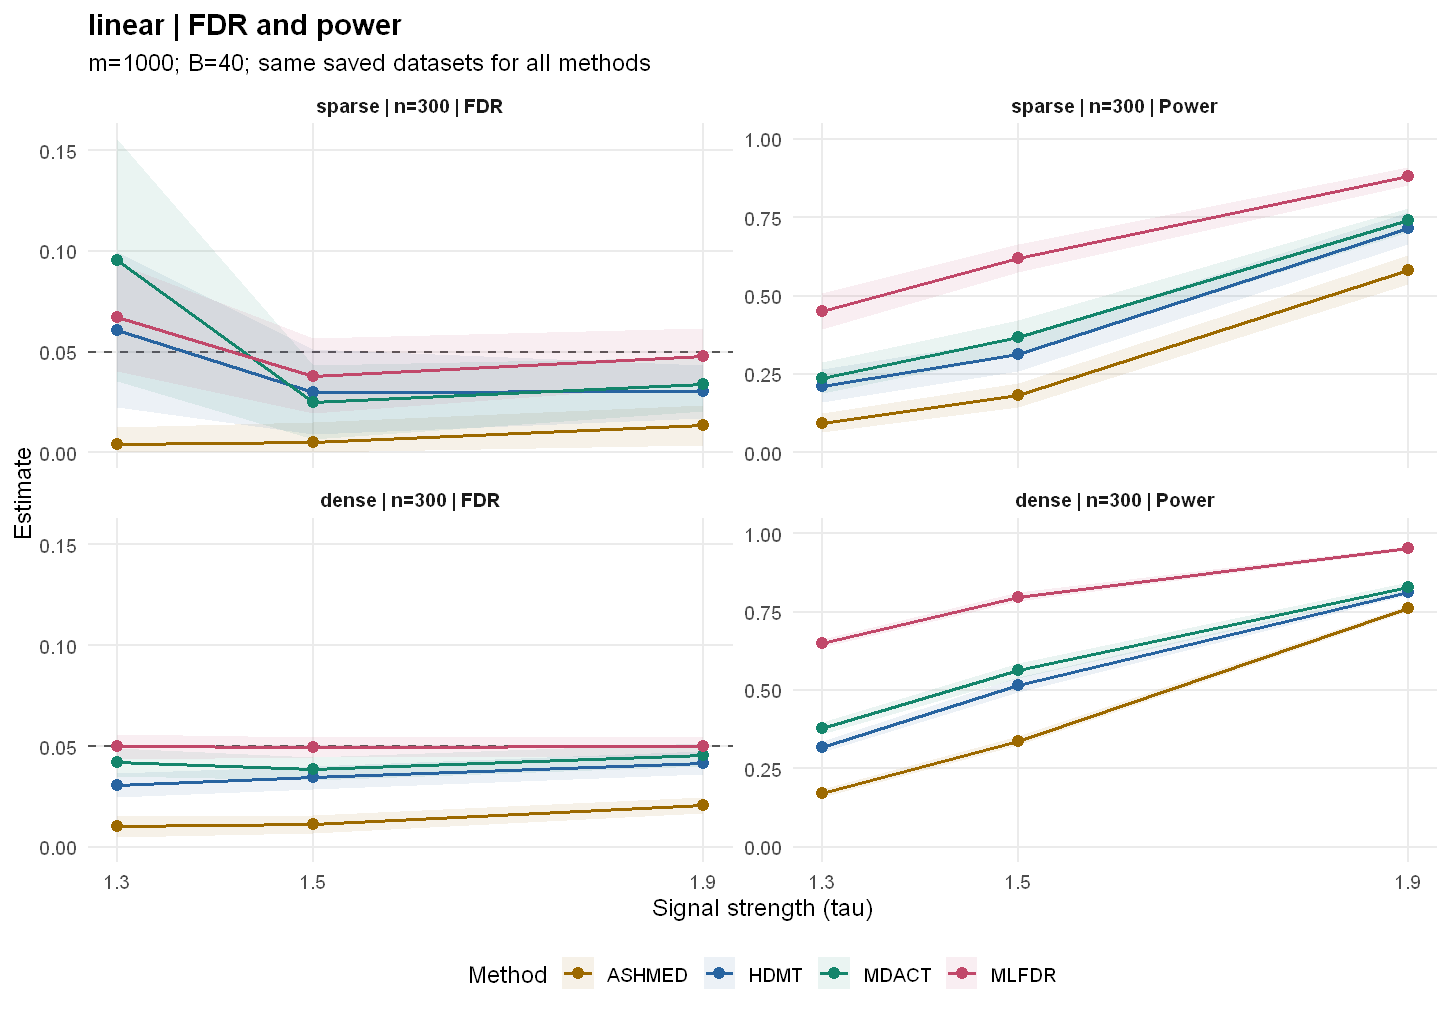

In [7]:
x <- suite[["teaching_fixed"]]
print(plot_ashmed_comparison(x$experiment$summary,"linear"))
tab <- x$experiment$summary[x$experiment$summary$scenario=="linear",
  c("mixture","tau","method","n_success","n_error","n_warning","FDR_mean","FDR_mcse","power_mean","power_mcse")]
numeric <- vapply(tab,is.numeric,logical(1))
tab[numeric] <- lapply(tab[numeric],round,4)
IRdisplay::display(tab)

### 已测混杂并调整Z

,mixture,tau,method,n_success,n_error,n_warning,FDR_mean,FDR_mcse,power_mean,power_mcse
,<chr>,<dbl>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
25,dense,1.3,ASHMED,40,0,0,0.0085,0.0023,0.1706,0.0052
26,dense,1.3,HDMT,40,0,40,0.0288,0.0028,0.3234,0.0091
27,dense,1.3,MDACT,40,0,40,0.0397,0.0032,0.3871,0.0091
28,dense,1.3,MLFDR,40,0,0,0.0489,0.0028,0.6648,0.0065
29,dense,1.5,ASHMED,40,0,0,0.0115,0.0020,0.3520,0.0076
30,dense,1.5,HDMT,40,0,40,0.0365,0.0039,0.5145,0.0071
31,dense,1.5,MDACT,40,0,40,0.0437,0.0041,0.5648,0.0075
32,dense,1.5,MLFDR,40,0,0,0.0528,0.0029,0.8138,0.0058
33,dense,1.9,ASHMED,40,0,0,0.0184,0.0017,0.7535,0.0079


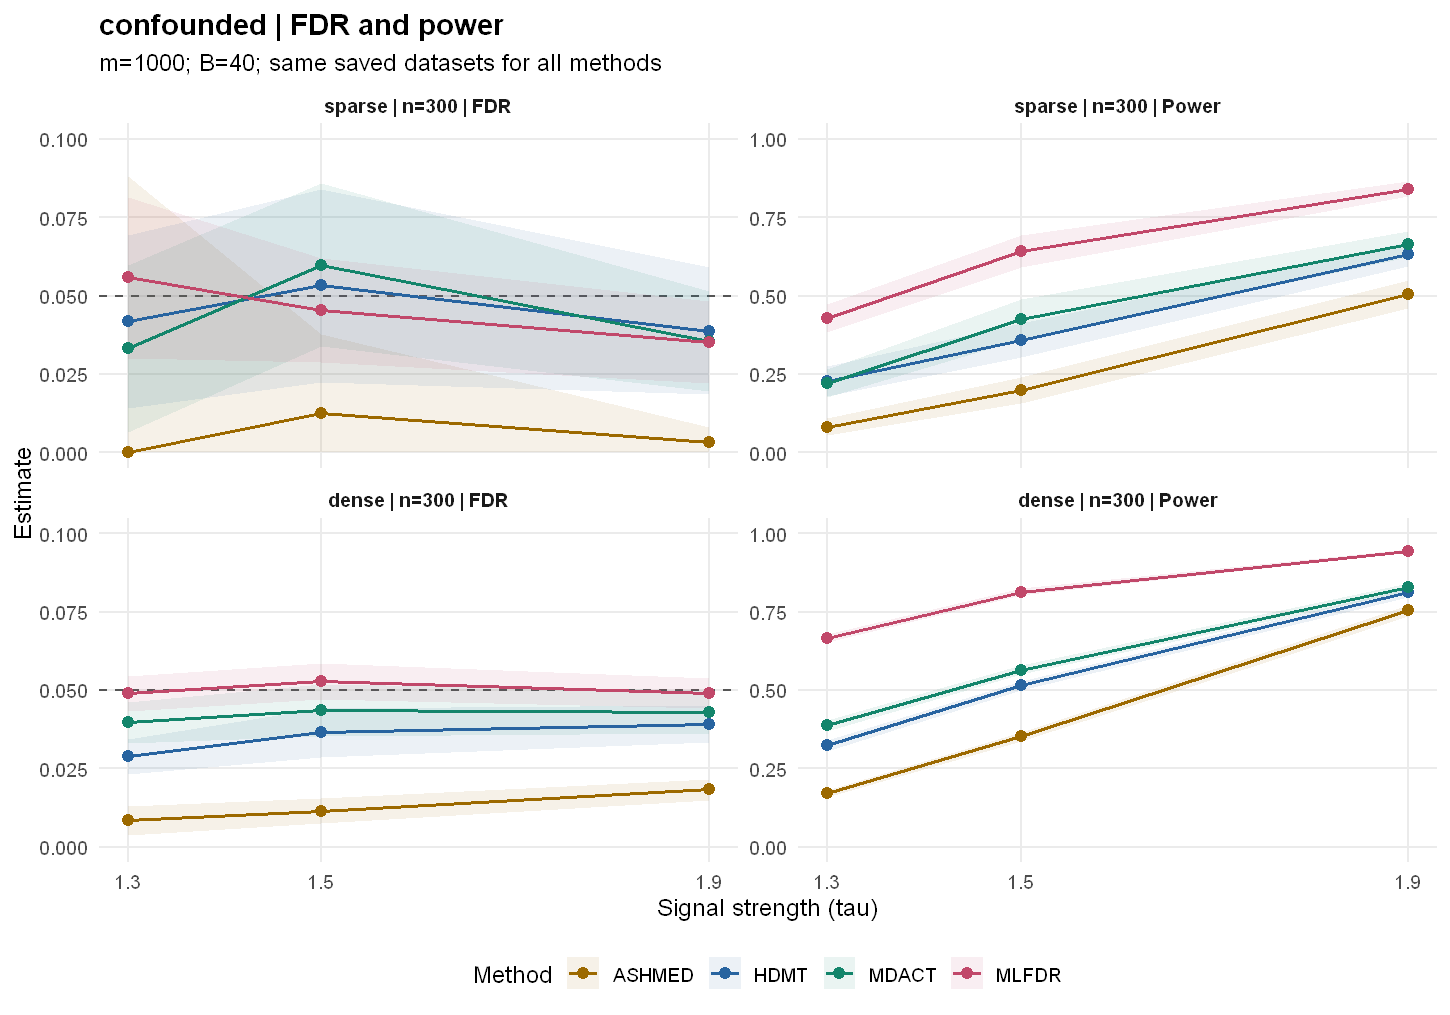

In [8]:
x <- suite[["teaching_fixed"]]
print(plot_ashmed_comparison(x$experiment$summary,"confounded"))
tab <- x$experiment$summary[x$experiment$summary$scenario=="confounded",
  c("mixture","tau","method","n_success","n_error","n_warning","FDR_mean","FDR_mcse","power_mean","power_mcse")]
numeric <- vapply(tab,is.numeric,logical(1))
tab[numeric] <- lapply(tab[numeric],round,4)
IRdisplay::display(tab)

### 二元结局：ASHMED使用GLM正态摘要扩展

,mixture,tau,method,n_success,n_error,n_warning,FDR_mean,FDR_mcse,power_mean,power_mcse
,<chr>,<dbl>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,dense,1.3,ASHMED,40,0,0,0.0504,0.0046,0.3693,0.0070
2,dense,1.3,HDMT,40,0,0,0.0252,0.0034,0.3260,0.0094
3,dense,1.3,MDACT,40,0,0,0.0331,0.0033,0.3838,0.0083
4,dense,1.3,MLFDR,40,0,0,0.0496,0.0021,0.6522,0.0065
5,dense,1.5,ASHMED,40,0,0,0.0358,0.0033,0.5378,0.0087
6,dense,1.5,HDMT,40,0,0,0.0295,0.0028,0.5098,0.0097
7,dense,1.5,MDACT,40,0,0,0.0377,0.0029,0.5650,0.0102
8,dense,1.5,MLFDR,40,0,0,0.0483,0.0031,0.8012,0.0060
9,dense,1.9,ASHMED,40,0,0,0.0447,0.0026,0.8442,0.0064


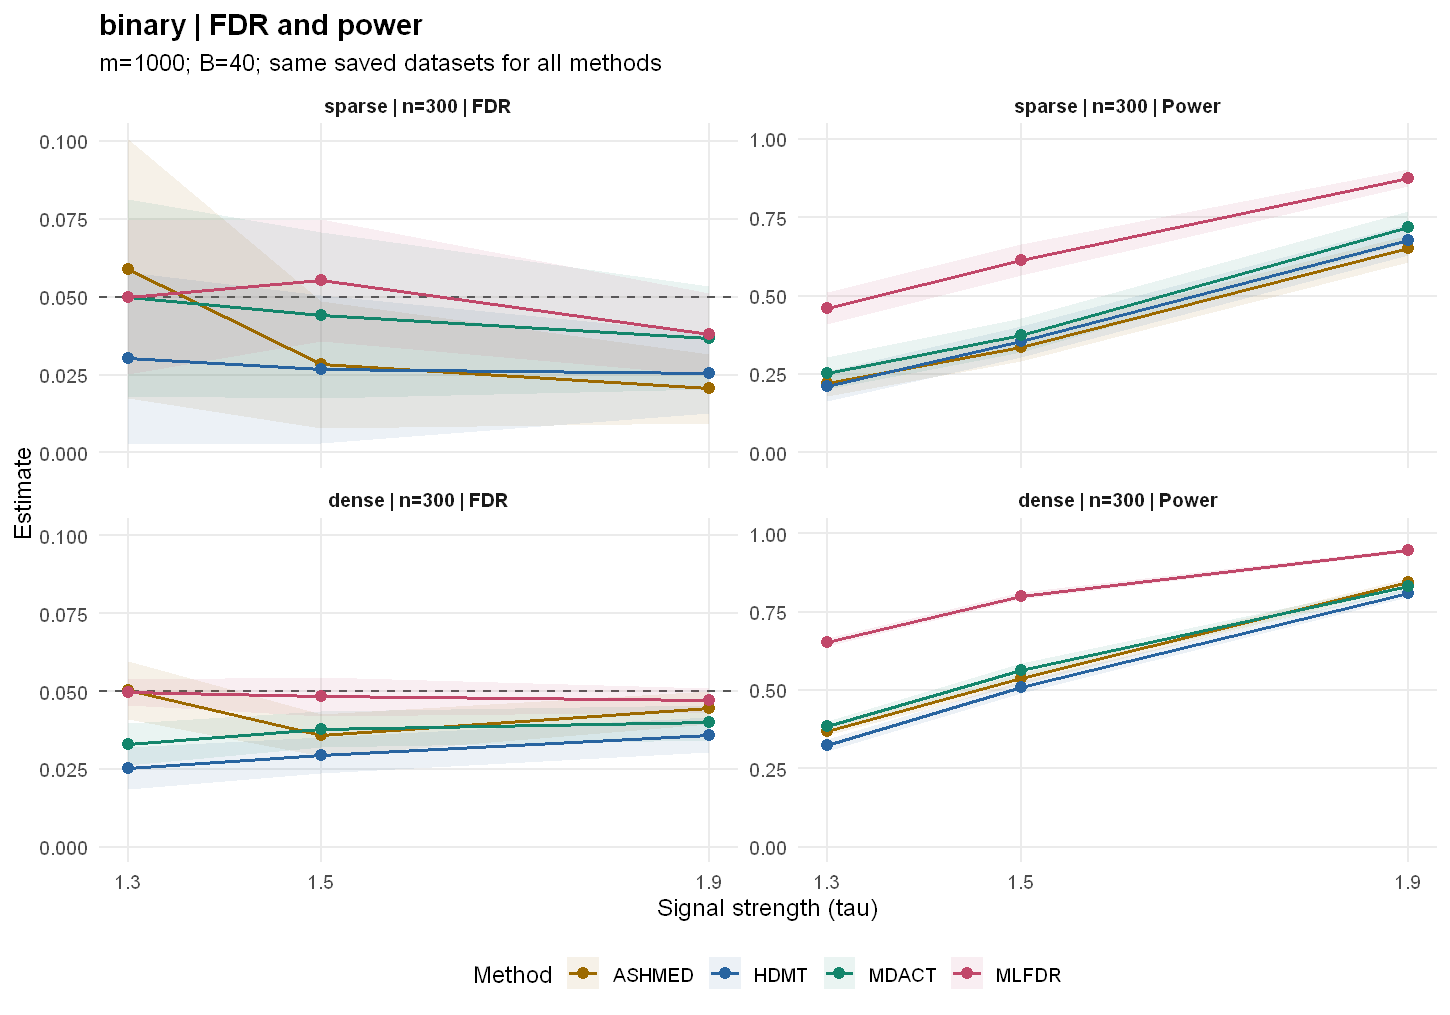

In [9]:
x <- suite[["teaching_fixed"]]
print(plot_ashmed_comparison(x$experiment$summary,"binary"))
tab <- x$experiment$summary[x$experiment$summary$scenario=="binary",
  c("mixture","tau","method","n_success","n_error","n_warning","FDR_mean","FDR_mcse","power_mean","power_mcse")]
numeric <- vapply(tab,is.numeric,logical(1))
tab[numeric] <- lapply(tab[numeric],round,4)
IRdisplay::display(tab)

## 同一数据内的配对比较

以下展示τ=1.5的“ASHMED−原方法”差异，单位为百分点。正值表示ASHMED较大，负值表示较小；FDR与Power需同时看。区间来自重复内配对差的近似t区间。全部τ的配对表保存在各结果目录的`paired_differences.csv`。

In [10]:
for (label in names(suite)) {
  paired <- suite[[label]]$paired
  tab <- paired[paired$tau==1.5,c("scenario","mixture","tau","comparison","n_pairs",
    "delta_FDR_mean","delta_power_mean","delta_power_lo","delta_power_hi")]
  for (key in c("delta_FDR_mean","delta_power_mean","delta_power_lo","delta_power_hi"))
    tab[[key]] <- round(100*tab[[key]],2)
  cat("\n",label,"\n")
  IRdisplay::display(tab)
}

,scenario,mixture,tau,comparison,n_pairs,delta_FDR_mean,delta_power_mean,delta_power_lo,delta_power_hi
,<chr>,<chr>,<dbl>,<chr>,<int>,<dbl>,<dbl>,<dbl>,<dbl>
7,binary,dense,1.5,ASHMED - HDMT,40,0.50,4.72,3.08,6.36
8,confounded,dense,1.5,ASHMED - HDMT,40,-2.30,-14.90,-16.54,-13.25
9,linear,dense,1.5,ASHMED - HDMT,40,-1.96,-14.66,-16.61,-12.72
10,binary,sparse,1.5,ASHMED - HDMT,40,0.08,2.56,-1.46,6.58
11,confounded,sparse,1.5,ASHMED - HDMT,40,-3.78,-15.15,-20.78,-9.53
12,linear,sparse,1.5,ASHMED - HDMT,40,-2.19,-10.55,-13.68,-7.42
25,binary,dense,1.5,ASHMED - MDACT,40,-0.20,0.19,-1.63,2.02
26,confounded,dense,1.5,ASHMED - MDACT,40,-3.07,-19.41,-21.26,-17.56
27,linear,dense,1.5,ASHMED - MDACT,40,-3.00,-18.92,-20.73,-17.10


,scenario,mixture,tau,comparison,n_pairs,delta_FDR_mean,delta_power_mean,delta_power_lo,delta_power_hi
,<chr>,<chr>,<dbl>,<chr>,<int>,<dbl>,<dbl>,<dbl>,<dbl>
7,binary,dense,1.5,ASHMED - HDMT,40,0.63,2.80,1.44,4.16
8,confounded,dense,1.5,ASHMED - HDMT,40,-2.50,-16.25,-17.79,-14.71
9,linear,dense,1.5,ASHMED - HDMT,40,-2.32,-17.86,-19.54,-16.18
10,binary,sparse,1.5,ASHMED - HDMT,40,0.17,-1.88,-6.12,2.37
11,confounded,sparse,1.5,ASHMED - HDMT,40,-4.08,-15.88,-20.54,-11.21
12,linear,sparse,1.5,ASHMED - HDMT,40,-2.52,-12.88,-16.77,-8.98
25,binary,dense,1.5,ASHMED - MDACT,40,-0.19,-2.72,-4.16,-1.29
26,confounded,dense,1.5,ASHMED - MDACT,40,-3.22,-21.27,-22.87,-19.68
27,linear,dense,1.5,ASHMED - MDACT,40,-2.75,-22.45,-24.23,-20.67



 paper_adjusted 

 teaching_fixed 


## 看懂一次拟合：四状态后验与收缩

两套均预先选择**线性、密集、τ=1.5、第1次重复**作示例。表格按local FDR排列，展示最先被发现的路径，完整1000条输出保存为`ashmed_example_posterior.csv`。真值在此时才加入，便于评估。下图比较回归估计与后验均值；α、β面板分别展示，虚线为不收缩的位置。

state,fitted_pi,observed_truth_fraction
<chr>,<dbl>,<dbl>
H00,0.07498144,0.423
H10,0.45583229,0.200
H01,0.33129332,0.186
H11,0.13789295,0.191


,pathway_id,truth_state,H00,H10,H01,H11,lfdr,reject,alpha_hat,alpha_mean,beta_hat,beta_mean,mediation_mean,mediation_sd
,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<lgl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
pathway_0693,pathway_0693,H11,1.151949e-54,5.217044e-50,4.139867e-05,0.9999586,4.139867e-05,TRUE,1.0469113,1.0562392,-0.8593933,-0.8456740,-0.8933448,0.1828070
pathway_0490,pathway_0490,H11,2.679776e-53,5.458299e-49,1.483179e-04,0.9998517,1.483179e-04,TRUE,0.9677071,0.9778823,-0.8592844,-0.8451371,-0.8265508,0.1770268
pathway_0217,pathway_0217,H11,2.909144e-36,2.349954e-32,2.695442e-04,0.9997305,2.695442e-04,TRUE,1.0332916,1.0370195,-0.6833246,-0.6731763,-0.6982211,0.1588005
pathway_0382,pathway_0382,H11,6.779021e-68,5.132904e-64,3.827693e-04,0.9996172,3.827693e-04,TRUE,0.9911586,1.0034357,-0.8926108,-0.8803789,-0.8835042,0.1946409
pathway_0468,pathway_0468,H11,3.571721e-26,2.656811e-22,6.519531e-04,0.9993480,6.519531e-04,TRUE,0.8689884,0.8722722,-0.6181720,-0.6072674,-0.5298126,0.1283202
pathway_0261,pathway_0261,H11,1.453190e-60,7.214144e-57,7.231244e-04,0.9992769,7.231244e-04,TRUE,0.9556614,0.9684159,-0.9001829,-0.8860234,-0.8581515,0.1956296
pathway_0292,pathway_0292,H11,7.633562e-40,3.526379e-36,7.315082e-04,0.9992685,7.315082e-04,TRUE,0.9544584,0.9605659,-0.7203549,-0.7094367,-0.6815749,0.1603843
pathway_0630,pathway_0630,H11,1.507313e-25,8.216324e-22,1.048676e-03,0.9989513,1.048676e-03,TRUE,0.8387267,0.8429120,-0.6465393,-0.6336354,-0.5342176,0.1323705
pathway_0999,pathway_0999,H11,4.118123e-41,1.098403e-37,1.421228e-03,0.9985788,1.421228e-03,TRUE,0.9370632,0.9419906,-0.6893429,-0.6801930,-0.6408391,0.1561658



 paper_adjusted 示例： linear_dense_n300_t02_r0001 


state,fitted_pi,observed_truth_fraction
<chr>,<dbl>,<dbl>
H00,0.04276515,0.4
H10,0.46219447,0.2
H01,0.36674463,0.2
H11,0.12829576,0.2


,pathway_id,truth_state,H00,H10,H01,H11,lfdr,reject,alpha_hat,alpha_mean,beta_hat,beta_mean,mediation_mean,mediation_sd
,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<lgl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
pathway_0129,pathway_0129,H11,2.691402e-34,8.209615e-30,0.0001413259,0.9998587,0.0001413259,TRUE,0.5720031,0.5745665,0.7167159,0.7039987,0.4045700,0.08955635
pathway_0167,pathway_0167,H11,7.783595e-42,1.595736e-37,0.0003291768,0.9996708,0.0003291768,TRUE,0.5281177,0.5321558,0.7658810,0.7531726,0.4008677,0.08983275
pathway_0125,pathway_0125,H11,3.140844e-41,1.976391e-37,0.0015097889,0.9984902,0.0015097889,TRUE,0.4987433,0.5032307,0.7822444,0.7685319,0.3868152,0.09331603
pathway_0609,pathway_0609,H11,4.416643e-43,2.320280e-39,0.0015712145,0.9984288,0.0015712145,TRUE,0.5152987,0.5192774,0.7570956,0.7453654,0.3871155,0.09362499
pathway_0893,pathway_0893,H11,2.049656e-35,9.345608e-32,0.0019625590,0.9980374,0.0019625590,TRUE,0.5057528,0.5089432,0.7224985,0.7100048,0.3614230,0.08977466
pathway_0778,pathway_0778,H11,1.214480e-28,4.071313e-25,0.0028414329,0.9971586,0.0028414329,TRUE,0.4979765,0.4987947,0.6177603,0.6082061,0.3034365,0.07872343
pathway_0158,pathway_0158,H11,1.229545e-40,4.080518e-37,0.0030217602,0.9969782,0.0030217602,TRUE,0.4957645,0.4992199,0.7471074,0.7351342,0.3670583,0.09292562
pathway_0917,pathway_0917,H11,2.766914e-28,1.196838e-24,0.0031992727,0.9968007,0.0031992727,TRUE,0.4529234,0.4553385,0.6905303,0.6764873,0.3080989,0.08009611
pathway_0922,pathway_0922,H11,7.476942e-47,2.623703e-43,0.0037304303,0.9962696,0.0037304303,TRUE,0.4667594,0.4712176,0.8106626,0.7972345,0.3757284,0.09538141



 teaching_fixed 示例： linear_dense_n300_t02_r0001 


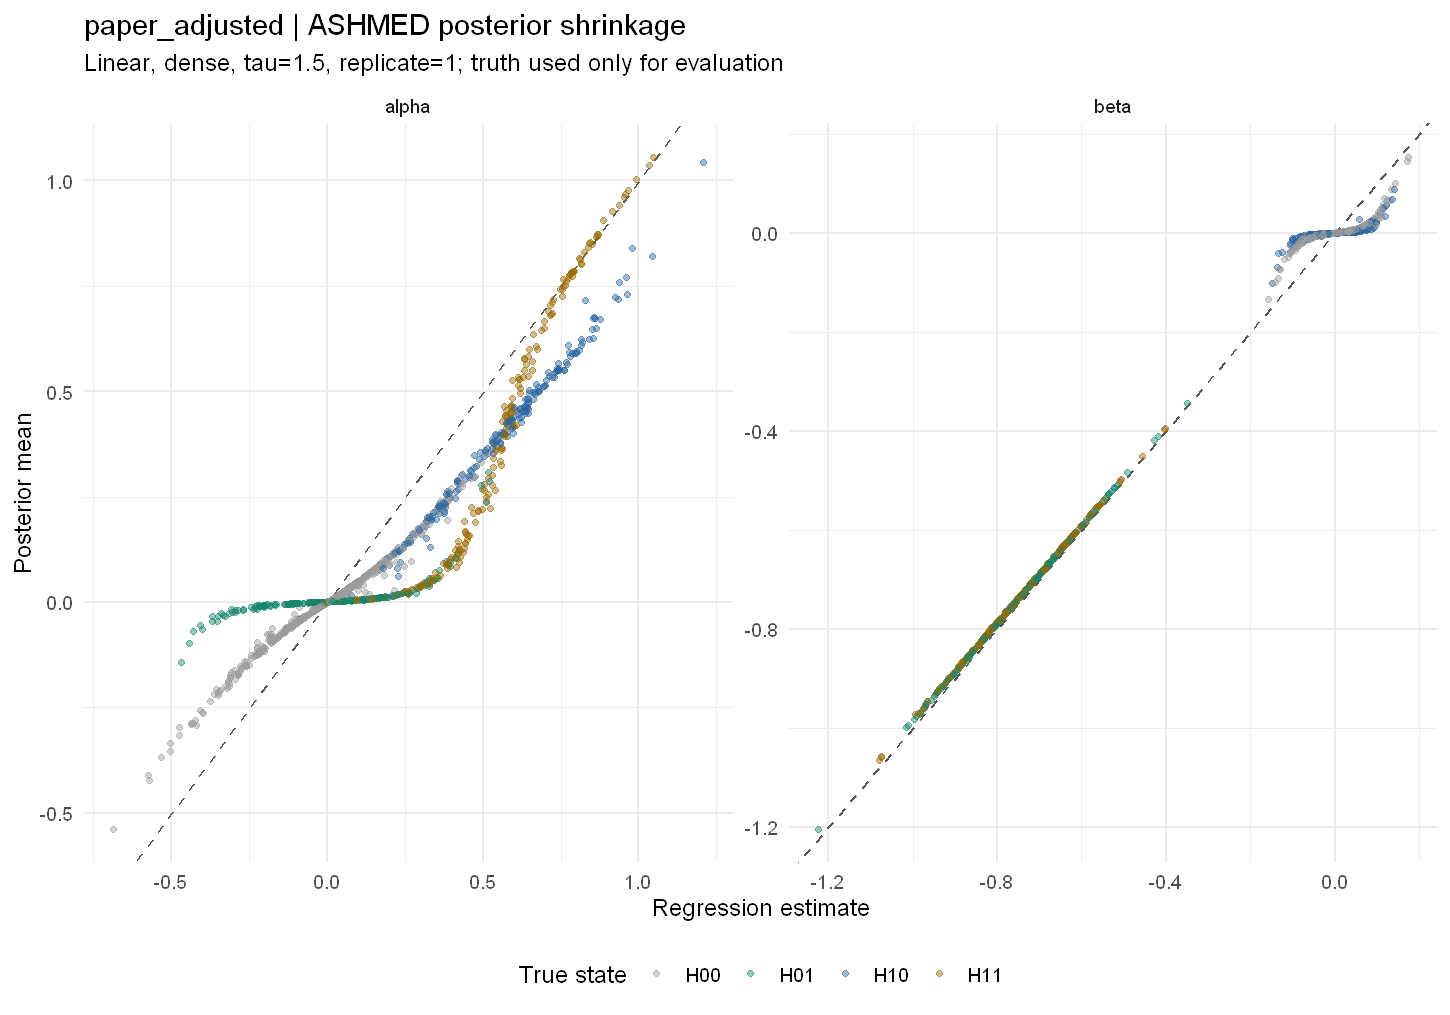

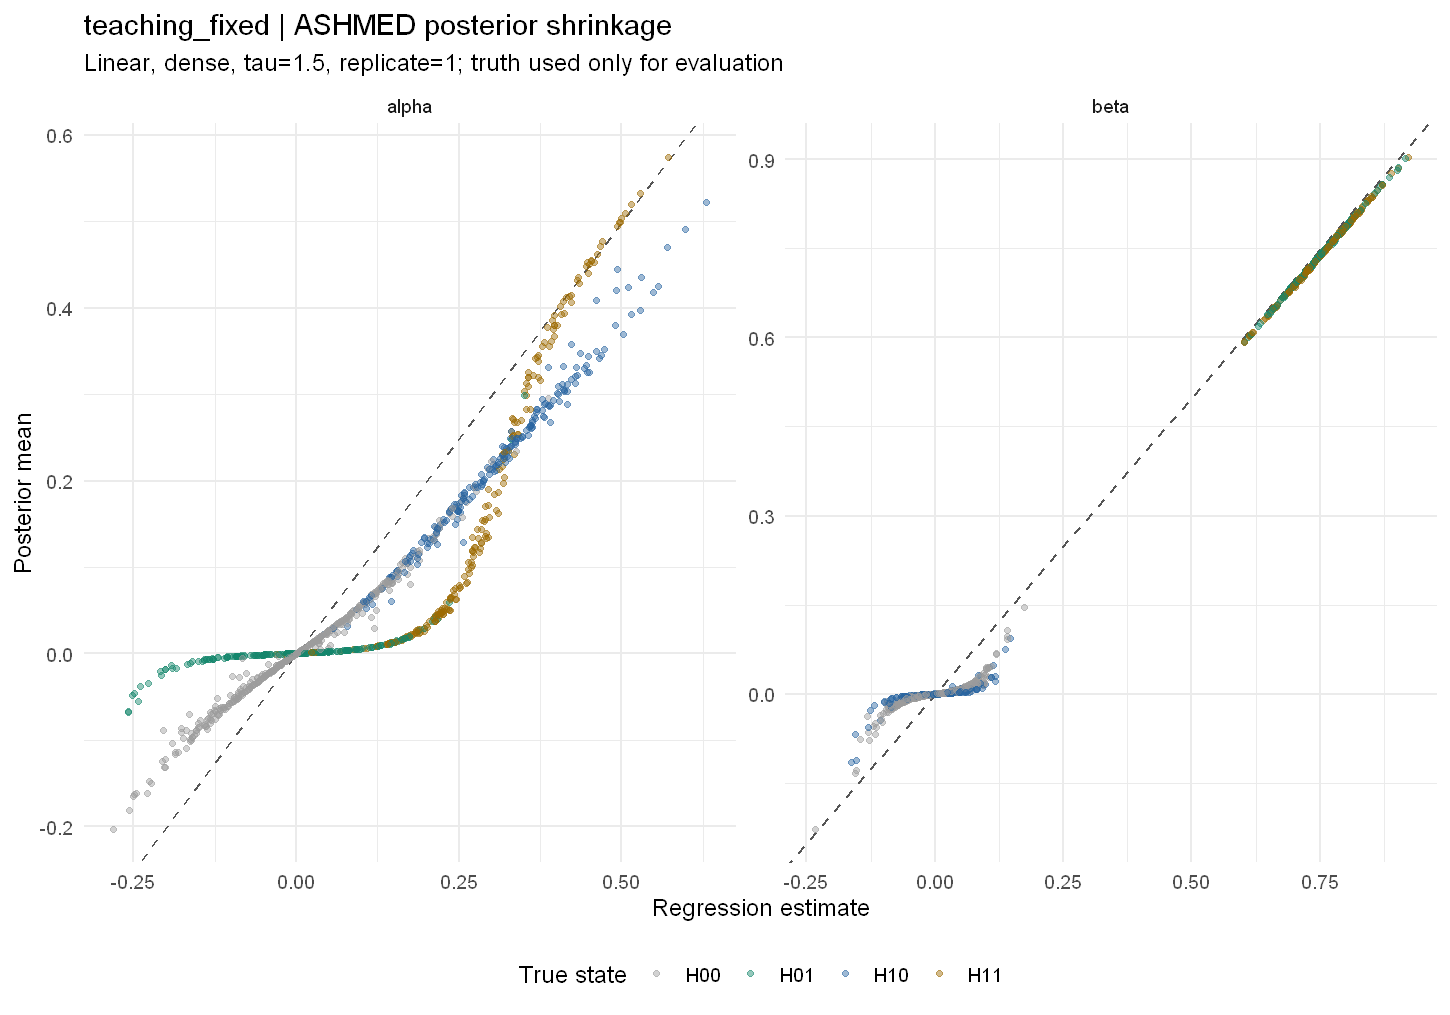

In [11]:
for (label in names(suite)) {
  x <- suite[[label]]
  p <- x$example$posterior
  cat("\n",label,"示例：",x$example$case_id,"\n")
  IRdisplay::display(data.frame(state=names(x$example$result$diagnostics$pi),
                               fitted_pi=unname(x$example$result$diagnostics$pi),
                               observed_truth_fraction=as.numeric(table(factor(p$truth_state,levels=c("H00","H10","H01","H11"))))/nrow(p)))
  top <- p[order(p$lfdr),c("pathway_id","truth_state","H00","H10","H01","H11","lfdr","reject",
    "alpha_hat","alpha_mean","beta_hat","beta_mean","mediation_mean","mediation_sd")]
  IRdisplay::display(head(top,10))
  long <- rbind(data.frame(link="alpha",estimate=p$alpha_hat,posterior_mean=p$alpha_mean,state=p$truth_state),
                data.frame(link="beta",estimate=p$beta_hat,posterior_mean=p$beta_mean,state=p$truth_state))
  graph <- ggplot2::ggplot(long,ggplot2::aes(estimate,posterior_mean,color=state))+
    ggplot2::geom_abline(slope=1,intercept=0,linetype=2,color="#555555")+
    ggplot2::geom_point(size=1.2,alpha=.45)+ggplot2::facet_wrap(~link,scales="free",ncol=2)+
    ggplot2::scale_color_manual(values=c(H00="#9B9B9B",H10="#2864A0",H01="#13856B",H11="#9C6900"))+
    ggplot2::theme_minimal(base_size=12)+ggplot2::theme(legend.position="bottom")+
    ggplot2::labs(title=paste(label,"| ASHMED posterior shrinkage"),
                  subtitle="Linear, dense, tau=1.5, replicate=1; truth used only for evaluation",
                  x="Regression estimate",y="Posterior mean",color="True state")
  print(graph)
  ggplot2::ggsave(file.path(x$experiment$output_dir,"figures/ashmed_shrinkage.png"),
                  graph,width=10,height=7,dpi=160,bg="white")
}

## 数值检查与校准提示

下面逐套报告ASHMED的优化收敛、KKT gap、选择集合的平均local FDR以及实际FDR范围。选择集合的平均local FDR≤0.05是模型内的估计；它与利用真值计算的经验FDR有不同含义。仍展示实际FDR偏高的条件，不调整阈值或删除重复。

FDR区间下限超过q是该条件的校准提示，近似区间与多条件检查不构成联合保证；区间跨过q也不能证明严格控制。原方法的历史警告继续保留在`diagnostics.csv`，通常涉及强β的p值并列；ASHMED优化警告另行展示。τ的趋势来自40次独立重复，有限Monte Carlo波动会使局部曲线不完全单调。

In [12]:
for (label in names(suite)) {
  x <- suite[[label]]
  fits <- x$fits
  s <- x$experiment$summary
  cat("\n",label,"\n")
  IRdisplay::display(data.frame(ashmed_fits=nrow(fits),converged=sum(fits$converged),
    max_iterations=max(fits$iterations),max_dual_gap=max(fits$dual_gap),
    max_selected_mean_lfdr=max(fits$selected_mean_lfdr,na.rm=TRUE)))
  IRdisplay::display(fits[!fits$converged,])
  flags <- s[is.finite(s$FDR_lo) & s$FDR_lo>s$q,
    c("scenario","mixture","tau","method","FDR_mean","FDR_lo","FDR_hi")]
  IRdisplay::display(flags)
  errors <- x$experiment$metrics[x$experiment$metrics$status!="ok",c("case_id","method","error")]
  IRdisplay::display(errors)
  stopifnot(all(x$experiment$metrics$status=="ok"),
            all(s$FDR_mean>=0 & s$FDR_mean<=1),all(s$power_mean>=0 & s$power_mean<=1),
            all(fits$selected_mean_lfdr[is.finite(fits$selected_mean_lfdr)]<=x$experiment$config$q+1e-12))
  ranges <- do.call(rbind,lapply(unique(s$method),function(method) {
    z <- s[s$method==method,]
    data.frame(method=method,FDR_min=min(z$FDR_mean),FDR_max=max(z$FDR_mean),
               power_min=min(z$power_mean),power_max=max(z$power_mean))
  }))
  IRdisplay::display(ranges)
  middle <- s[s$scenario=="linear" & s$mixture=="dense" & s$tau==1.5,]
  lines <- vapply(seq_len(nrow(middle)),function(i)
    sprintf("%s：FDR %.4f，Power %.4f",middle$method[i],middle$FDR_mean[i],middle$power_mean[i]),character(1))
  IRdisplay::display_markdown(paste0("**",label,"，线性密集τ=1.5的真实结果：** ",paste(lines,collapse="；"),"。"))
}

ashmed_fits,converged,max_iterations,max_dual_gap,max_selected_mean_lfdr
<int>,<int>,<int>,<dbl>,<dbl>
720,720,1597,9.984389e-05,0.04999782


case_id,scenario,mixture,tau,converged,iterations,dual_gap,loglik,pi00,pi10,pi01,pi11,discoveries,selected_mean_lfdr,n_fit,n_components,likelihood
<chr>,<chr>,<chr>,<dbl>,<lgl>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<int>,<dbl>,<int>,<int>,<chr>


,scenario,mixture,tau,method,FDR_mean,FDR_lo,FDR_hi
,<chr>,<chr>,<dbl>,<chr>,<dbl>,<dbl>,<dbl>
9,binary,dense,1.9,ASHMED,0.06688941,0.05810007,0.07567875
56,linear,dense,1.5,MLFDR,0.05601047,0.05047409,0.06154686


case_id,method,error
<chr>,<chr>,<chr>


method,FDR_min,FDR_max,power_min,power_max
<chr>,<dbl>,<dbl>,<dbl>,<dbl>
ASHMED,0.00250000,0.06688941,0.1171928,0.8809141
HDMT,0.01367244,0.06313802,0.2262791,0.8448240
MDACT,0.01010101,0.06600136,0.2516976,0.8559568
MLFDR,0.03520890,0.07553304,0.4488875,0.9546096


...

scenario,mixture,tau,method,FDR_mean,FDR_lo,FDR_hi
<chr>,<chr>,<dbl>,<chr>,<dbl>,<dbl>,<dbl>


case_id,method,error
<chr>,<chr>,<chr>


method,FDR_min,FDR_max,power_min,power_max
<chr>,<dbl>,<dbl>,<dbl>,<dbl>
ASHMED,0.00000000,0.05900072,0.08125,0.844250
HDMT,0.02524127,0.06096501,0.21250,0.812500
MDACT,0.02507659,0.09556055,0.22125,0.830375
MLFDR,0.03522625,0.06725136,0.42750,0.953000


**teaching_fixed，线性密集τ=1.5的真实结果：** ASHMED：FDR 0.0113，Power 0.3385；HDMT：FDR 0.0345，Power 0.5171；MDACT：FDR 0.0388，Power 0.5630；MLFDR：FDR 0.0496，Power 0.7979。


 paper_adjusted 

 teaching_fixed 


## 如何解释四种方法的差别

ASHMED以零为中心混合多个尺度，并在H11中学习ρ成分权重；MLFDR的`paper_em`后端学习非零效应均值及四类密度；HDMT/MDACT主要利用两段p值和复合零假设分布。两套历史数据的非零效应有明确方向，第二套还使用固定非零效应，因此零中心的ASHMED先验未必适合；它的same-scale构造也限制了α和β先验方差的相对大小。

如果ASHMED有较低实际FDR、同时Power较低，首先解释为更保守的筛选和模型适配差别。**本实验没有把ASHMED改成非零均值先验，也没有依据真值调优网格。** 两套实验内的配对比较可以支持当前条件下的差别，不能由此宣称某个方法对所有效应分布都更好。二元结果还受到GLM摘要近似的限制。

ASHMED的收缩SD和四状态后验提供额外解释，但经验贝叶斯拟合没有纳入混合权重估计误差；其local FDR阈值也不自动保证任意错设模型下的频率学FDR。这里展示真实FDR/Power正是为了检验这一区别。

## 修改、复用与输出文件

- 方法实现：`R/methods/plugins/ashmed.R`；数学及补全说明：`docs/ASHMED_METHOD.md`。插件只依赖基础R，不安装ASHMED包。
- 比较调度：`R/ashmed_comparison.R`。保存manifest和三方法基线配置一一对应；开头`SAVED_SOURCES`集中更换已有文件入口。缺少文件会明确报错，此notebook不会生成替代数据。
- 新方法：按`docs/ADDING_METHODS.md`注册插件，再给`ADDITIONAL_METHOD_OPTIONS`追加具名项，如`NEW=list(...)`。原方法参数保持不变；数据不用生成，不变方法的缓存可复用。
- 各独立结果目录含`summary.csv`、`replicate_metrics.csv`、`paired_differences.csv`、`ashmed_fit_diagnostics.csv`、`fit_diagnostics.csv`、`baseline_audit.csv`、`data_audit.csv`、示例后验/成分/优化轨迹、PNG主图及运行配置/环境/源码指纹。
- 新入口是`docs/current_ashmed.rds`/`.txt`，原两个入口和notebook不覆盖。运行报告见`docs/ASHMED_RUN_REPORT.md`。
- 批量执行：`python scripts/execute_notebook.py notebooks/03_ashmed_comparison.ipynb`；命令行比较：`Rscript --vanilla scripts/run_ashmed.R`。
- 数学检查：`Rscript --vanilla tests/check_ashmed.R`；交付结果检查：`Rscript --vanilla scripts/validate_ashmed.R`。作者脚本`build_ashmed_notebook.py`会覆盖本notebook输出及手工编辑，日常调参直接改notebook。